In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

from google.colab import drive

In [2]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# PROJECT PATHS
# ============================================================

CSV_PATH = "/content/drive/MyDrive/Research_Project/unified_glaucoma_dataset.csv"

OUTPUT_FOLDER = "/content/drive/MyDrive/Research_Project/Processed_Dataset"

OUTPUT_CSV = "/content/drive/MyDrive/Research_Project/processed_dataset.csv"

IMG_SIZE = (256,256)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Project Paths Loaded Successfully")

Project Paths Loaded Successfully


In [4]:
# ============================================================
# LOAD UNIFIED CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print(df.head())

print("\nTotal Images :",len(df))

  image_name                                         image_path  label  \
0    072.jpg  /content/drive/MyDrive/Research_Project/Datase...      1   
1    086.jpg  /content/drive/MyDrive/Research_Project/Datase...      1   
2    036.jpg  /content/drive/MyDrive/Research_Project/Datase...      1   
3    076.jpg  /content/drive/MyDrive/Research_Project/Datase...      1   
4    087.jpg  /content/drive/MyDrive/Research_Project/Datase...      1   

  label_name dataset  
0   Glaucoma   ORIGA  
1   Glaucoma   ORIGA  
2   Glaucoma   ORIGA  
3   Glaucoma   ORIGA  
4   Glaucoma   ORIGA  

Total Images : 1425


In [5]:
# ============================================================
# VERIFY IMAGE LOADING
# ============================================================

sample_path = df.iloc[0]["image_path"]

image = cv2.imread(sample_path)

print("Image Shape :",image.shape)

Image Shape : (2048, 3072, 3)


(np.float64(-0.5), np.float64(3071.5), np.float64(2047.5), np.float64(-0.5))

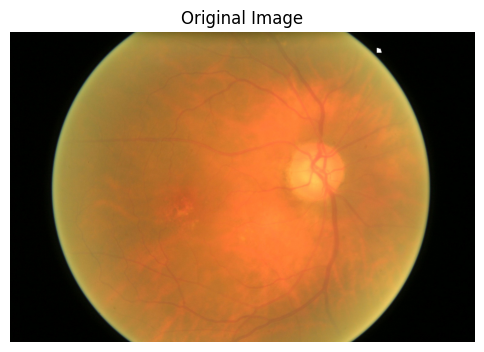

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

plt.title("Original Image")

plt.axis("off")

In [7]:
# ============================================================
# IMAGE QUALITY ANALYSIS
# ============================================================

def analyze_quality(image):

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)

    contrast = np.std(gray)

    sharpness = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    return brightness,contrast,sharpness

In [8]:
brightness,contrast,sharpness = analyze_quality(image)

print("Brightness :",brightness)

print("Contrast :",contrast)

print("Sharpness :",sharpness)

Brightness : 99.80580806732178
Contrast : 63.5016950070773
Sharpness : 12.509736426075042


In [9]:
# ============================================================
# CLAHE
# ============================================================

def apply_clahe(image):

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))

    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

In [10]:
# ============================================================
# GAMMA CORRECTION
# ============================================================

def gamma_correction(image, gamma=1.5):

    inv_gamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

In [11]:
# ============================================================
# BILATERAL FILTER
# ============================================================

def bilateral_filter(image):

    return cv2.bilateralFilter(
        image,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

In [12]:
# ============================================================
# UNSHARP MASK
# ============================================================

def unsharp_mask(image):

    blur = cv2.GaussianBlur(image, (5,5), 0)

    sharpened = cv2.addWeighted(
        image,
        1.5,
        blur,
        -0.5,
        0
    )

    return sharpened

In [24]:
# ============================================================
# ADAPTIVE PREPROCESSING WITH QUALITY METRICS
# ============================================================

def adaptive_preprocessing(image):

    # Analyze image quality
    brightness, contrast, sharpness = analyze_quality(image)

    processed = image.copy()

    operations = []

    # Low Contrast
    if contrast < 40:
        processed = apply_clahe(processed)
        operations.append("CLAHE")

    # Dark Image
    if brightness < 80:
        processed = gamma_correction(processed)
        operations.append("Gamma Correction")

    # Blurry Image
    if sharpness < 80:
        processed = unsharp_mask(processed)
        operations.append("Unsharp Mask")

    # Always apply noise reduction
    processed = bilateral_filter(processed)
    operations.append("Bilateral Filter")

    # Resize
    processed = cv2.resize(processed, IMG_SIZE)

    if operations == ["Bilateral Filter"]:
        operations.append("No Adaptive Enhancement")

    return processed, operations, brightness, contrast, sharpness

In [25]:
processed, operations, brightness, contrast, sharpness = adaptive_preprocessing(image)

print("Brightness :", brightness)
print("Contrast   :", contrast)
print("Sharpness  :", sharpness)

print("\nOperations Applied:")

for op in operations:
    print("✓", op)

Brightness : 99.80580806732178
Contrast   : 63.5016950070773
Sharpness  : 12.509736426075042

Operations Applied:
✓ Unsharp Mask
✓ Bilateral Filter


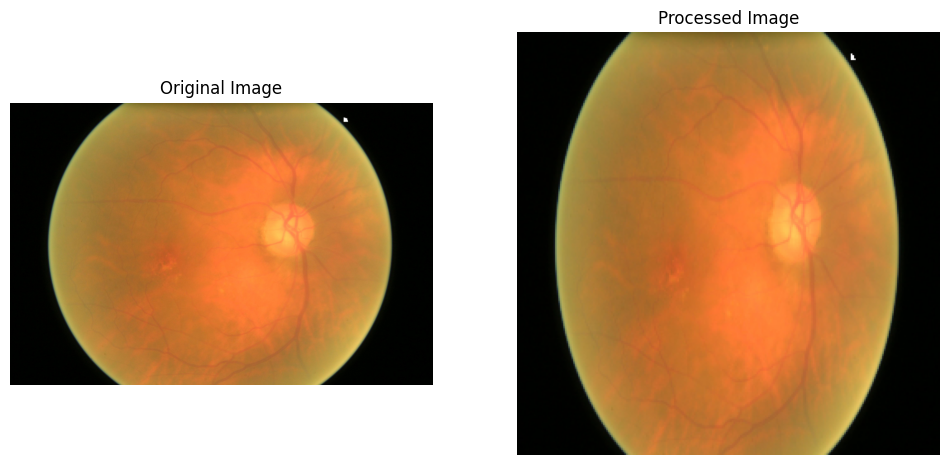


Preprocessing Operations Applied
✓ Unsharp Mask
✓ Bilateral Filter


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
plt.title("Processed Image")
plt.axis("off")

plt.show()

print("\nPreprocessing Operations Applied")

for op in operations:
    print("✓", op)

In [26]:
# ============================================================
# PROCESS ENTIRE DATASET
# ============================================================

processed_records = []

print("Starting Adaptive Preprocessing...\n")

for index, row in tqdm(df.iterrows(), total=len(df)):

    image_path = row["image_path"]

    image = cv2.imread(image_path)

    if image is None:
        continue

    # Adaptive preprocessing
    processed, operations, brightness, contrast, sharpness = adaptive_preprocessing(image)

    dataset = row["dataset"]

    output_dataset_folder = os.path.join(OUTPUT_FOLDER, dataset)

    os.makedirs(output_dataset_folder, exist_ok=True)

    output_path = os.path.join(
        output_dataset_folder,
        row["image_name"]
    )

    cv2.imwrite(output_path, processed)

    processed_records.append({

        "image_name": row["image_name"],

        "processed_image_path": output_path,

        "label": row["label"],

        "label_name": row["label_name"],

        "dataset": dataset,

        "brightness": round(brightness,2),

        "contrast": round(contrast,2),

        "sharpness": round(sharpness,2),

        "preprocessing": ", ".join(operations)

    })

print("\n✅ All Images Processed Successfully")

Starting Adaptive Preprocessing...



100%|██████████| 1425/1425 [33:51<00:00,  1.43s/it]


✅ All Images Processed Successfully


In [27]:
# ============================================================
# CREATE PROCESSED DATAFRAME
# ============================================================

processed_df = pd.DataFrame(processed_records)

print(processed_df.head())

print("\nTotal Processed Images :", len(processed_df))

  image_name                               processed_image_path  label  \
0    072.jpg  /content/drive/MyDrive/Research_Project/Proces...      1   
1    086.jpg  /content/drive/MyDrive/Research_Project/Proces...      1   
2    036.jpg  /content/drive/MyDrive/Research_Project/Proces...      1   
3    076.jpg  /content/drive/MyDrive/Research_Project/Proces...      1   
4    087.jpg  /content/drive/MyDrive/Research_Project/Proces...      1   

  label_name dataset  brightness  contrast  sharpness  \
0   Glaucoma   ORIGA       99.81     63.50      12.51   
1   Glaucoma   ORIGA       84.32     59.25      13.31   
2   Glaucoma   ORIGA       70.42     48.43      14.60   
3   Glaucoma   ORIGA       87.26     57.95       4.94   
4   Glaucoma   ORIGA       86.04     56.88      13.77   

                                      preprocessing  
0                    Unsharp Mask, Bilateral Filter  
1                    Unsharp Mask, Bilateral Filter  
2  Gamma Correction, Unsharp Mask, Bilateral Filte

In [28]:
# ============================================================
# SAVE PROCESSED CSV
# ============================================================

processed_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("✅ Processed CSV Saved Successfully")

print("\nLocation")

print(OUTPUT_CSV)

✅ Processed CSV Saved Successfully

Location
/content/drive/MyDrive/Research_Project/processed_dataset.csv


In [29]:
# ============================================================
# DATASET SUMMARY
# ============================================================

print("="*50)

print("Dataset Distribution")

print("="*50)

print(processed_df["dataset"].value_counts())

print("\n")

print("="*50)

print("Class Distribution")

print("="*50)

print(processed_df["label_name"].value_counts())

Dataset Distribution
dataset
ORIGA         520
RIM-ONE DL    485
PAPILA        420
Name: count, dtype: int64


Class Distribution
label_name
Normal      1032
Glaucoma     393
Name: count, dtype: int64


Image : 375.jpg
Label : Normal
Operations : Gamma Correction, Unsharp Mask, Bilateral Filter


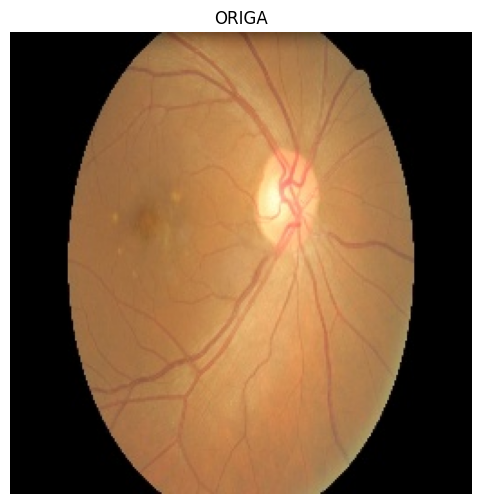

In [30]:
# ============================================================
# DISPLAY RANDOM PROCESSED IMAGE
# ============================================================

import random

sample = processed_df.sample(1).iloc[0]

img = cv2.imread(sample["processed_image_path"])

plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.title(sample["dataset"])

plt.axis("off")

print("Image :", sample["image_name"])

print("Label :", sample["label_name"])

print("Operations :", sample["preprocessing"])